# Supermarket Sales Analysis
## Data Analytics Project

**Objective:** Analyze supermarket sales data to discover useful information about products, branches, categories, customers, payment methods, and customer ratings.

### Problem Statement
The aim of this project is to analyze supermarket sales data and find useful information about products, branches, categories, customers, payments, and ratings.

### Dataset
The dataset contains **500 sales transactions** with information such as invoice ID, date, branch, city, customer type, gender, product, category, quantity, unit price, payment method, rating, and sales.

### Analysis Workflow
1. Collect and load the CSV dataset.
2. Check the data for missing or incorrect values.
3. Calculate **Sales = Quantity × Unit Price**.
4. Group and summarize the data using totals, counts, and averages.
5. Create charts to compare the results.
6. Use the results to make business decisions.


In [22]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [23]:
# Load the supermarket sales CSV dataset
file_path = "SUPER MARKET DATA - supermarket_sales_500_rows.csv"

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (500, 13)


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


## 1. Dataset Overview

In [24]:
# Basic information about the dataset
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Number of rows: 500
Number of columns: 13

Column names:
['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']

Data types:


,Data Type
Invoice ID,object
Date,object
Branch,object
City,object
Customer Type,object
Gender,object
Product,object
Category,object
Quantity,int64
Unit Price,float64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice ID,500,500,INV0500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,500,173,2026-01-12,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,500,4,C,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,500,4,Mumbai,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,500,2,Member,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,500,2,Female,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,500,20,Rice,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,500,8,Grocery,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,500.00,NaN,NaN,NaN,5.54,2.88,1.00,3.00,5.50,8.00,10.00
Unit Price,500.00,NaN,NaN,NaN,88.66,57.28,27.67,43.95,61.88,128.57,236.71


## 2. Data Quality Check
Check for missing values, duplicate rows, invalid quantities/prices/ratings, and verify the sales calculation.

In [25]:
# Missing values
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values.to_frame("Missing Values"))

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Basic validity checks
print("Rows with quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Rows with unit price <= 0:", (df["Unit Price"] <= 0).sum())
print("Ratings outside 1-5:", ((df["Rating"] < 1) | (df["Rating"] > 5)).sum())

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print("Invalid dates after conversion:", df["Date"].isna().sum())


,Missing Values
Invoice ID,0
Date,0
Branch,0
City,0
Customer Type,0
Gender,0
Product,0
Category,0
Quantity,0
Unit Price,0


Duplicate rows: 0
Rows with quantity <= 0: 0
Rows with unit price <= 0: 0
Ratings outside 1-5: 0
Invalid dates after conversion: 0


## 3. Calculate and Verify Sales
The project specification defines **Sales = Quantity × Unit Price**.

In [26]:
# Calculate sales independently from quantity and unit price
df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]

# Compare calculated sales with the Sales column
df["Sales Difference"] = (df["Sales"] - df["Calculated Sales"]).abs()

print("Maximum sales calculation difference:",
      df["Sales Difference"].max())

print("Rows where sales does not match Quantity × Unit Price:",
      (df["Sales Difference"] > 0.01).sum())

# Remove helper columns after verification
df.drop(columns=["Calculated Sales", "Sales Difference"], inplace=True)

display(df.head())


Maximum sales calculation difference: 4.547473508864641e-13
Rows where sales does not match Quantity × Unit Price: 0


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


## 4. Summary Statistics

In [27]:
summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Sales",
        "Average Transaction Sales",
        "Total Quantity Sold",
        "Average Customer Rating"
    ],
    "Value": [
        len(df),
        df["Sales"].sum(),
        df["Sales"].mean(),
        df["Quantity"].sum(),
        df["Rating"].mean()
    ]
})

display(summary)


,Metric,Value
0,Total Transactions,500.00
1,Total Sales,"244,411.08"
2,Average Transaction Sales,488.82
3,Total Quantity Sold,"2,768.00"
4,Average Customer Rating,3.99


## 5. Product-wise Sales Analysis

In [28]:
product_sales = (
    df.groupby("Product", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(product_sales)

top_product = product_sales.iloc[0]
print(f"Highest-selling product: {top_product['Product']}")
print(f"Sales: ₹{top_product['Sales']:,.2f}")


,Product,Sales
4,Cheese,"27,906.30"
7,Coffee,"27,694.87"
16,Shampoo,"27,497.48"
9,Cooking Oil,"21,525.06"
18,Tea,"17,681.59"
0,Apples,"17,057.41"
11,Face Wash,"11,946.85"
15,Rice,"11,754.17"
8,Cold Drink,"10,731.78"
10,Eggs,"10,429.77"


Highest-selling product: Cheese
Sales: ₹27,906.30


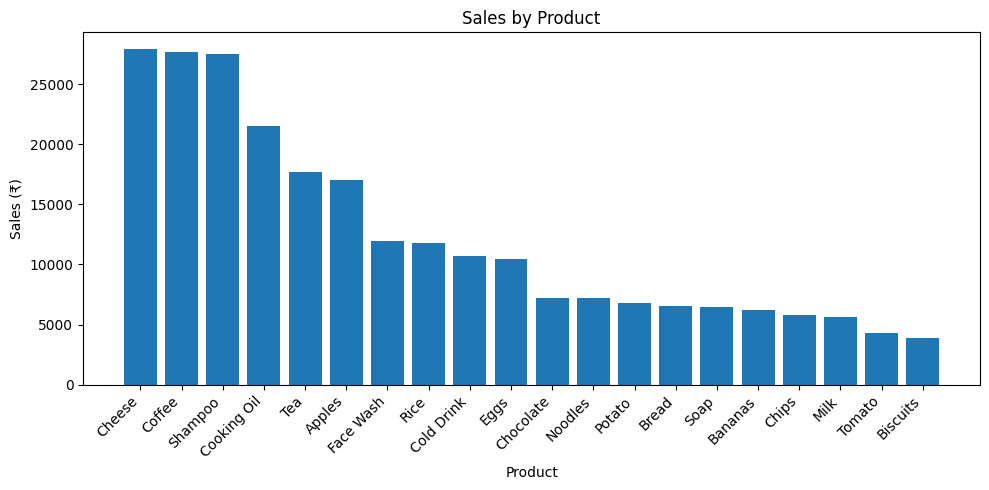

In [29]:
# Product sales chart
plt.figure(figsize=(10, 5))
plt.bar(product_sales["Product"], product_sales["Sales"])
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Branch-wise Sales Analysis

In [30]:
branch_sales = (
    df.groupby(["Branch", "City"], as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(branch_sales)

top_branch = branch_sales.iloc[0]
print(f"Best-performing branch: Branch {top_branch['Branch']} ({top_branch['City']})")
print(f"Sales: ₹{top_branch['Sales']:,.2f}")


,Branch,City,Sales
2,C,Mumbai,"72,469.45"
1,B,Delhi,"64,116.26"
3,D,Bengaluru,"55,468.29"
0,A,Jaipur,"52,357.08"


Best-performing branch: Branch C (Mumbai)
Sales: ₹72,469.45


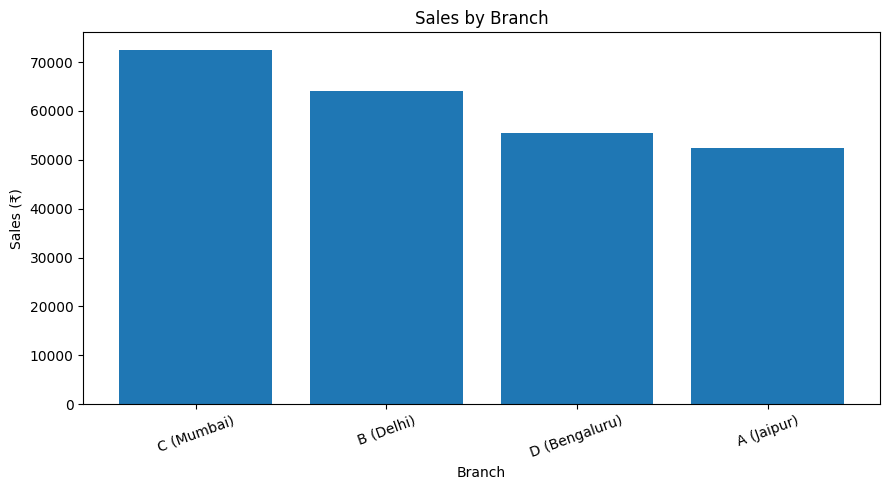

In [31]:
# Branch sales chart
labels = branch_sales["Branch"] + " (" + branch_sales["City"] + ")"

plt.figure(figsize=(9, 5))
plt.bar(labels, branch_sales["Sales"])
plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Category-wise Sales Analysis

In [32]:
category_sales = (
    df.groupby("Category", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(category_sales)

top_category = category_sales.iloc[0]
print(f"Highest-selling category: {top_category['Category']}")
print(f"Sales: ₹{top_category['Sales']:,.2f}")


,Category,Sales
1,Beverages,"56,108.24"
5,Personal Care,"45,943.96"
2,Dairy,"43,992.00"
4,Grocery,"40,470.47"
3,Fruits,"23,263.17"
6,Snacks,"16,992.97"
7,Vegetables,"11,124.17"
0,Bakery,"6,516.10"


Highest-selling category: Beverages
Sales: ₹56,108.24


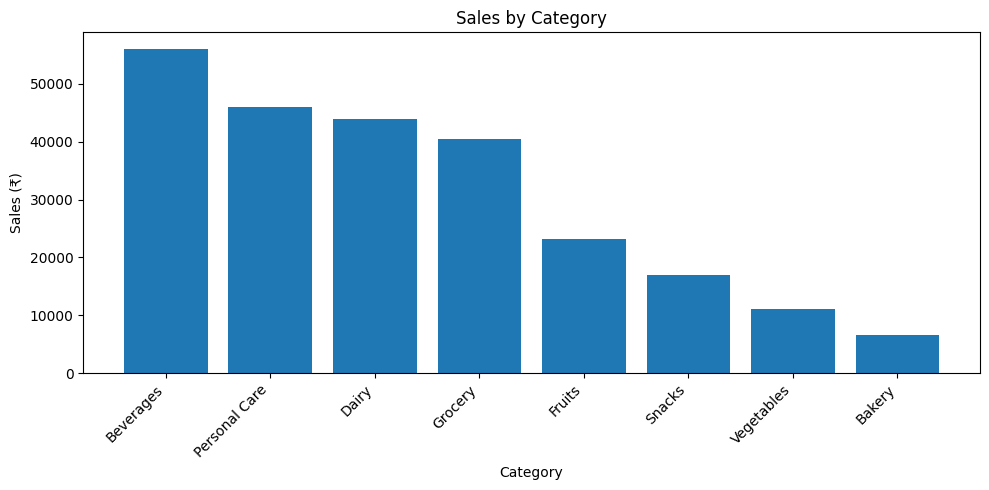

In [33]:
# Category sales chart
plt.figure(figsize=(10, 5))
plt.bar(category_sales["Category"], category_sales["Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Payment Method Analysis

In [34]:
payment_counts = (
    df["Payment"]
      .value_counts()
      .rename_axis("Payment Method")
      .reset_index(name="Transactions")
)

display(payment_counts)

top_payment = payment_counts.iloc[0]
print(f"Most popular payment method: {top_payment['Payment Method']}")
print(f"Transactions: {top_payment['Transactions']}")


,Payment Method,Transactions
0,UPI,127
1,Net Banking,126
2,Card,125
3,Cash,122


Most popular payment method: UPI
Transactions: 127


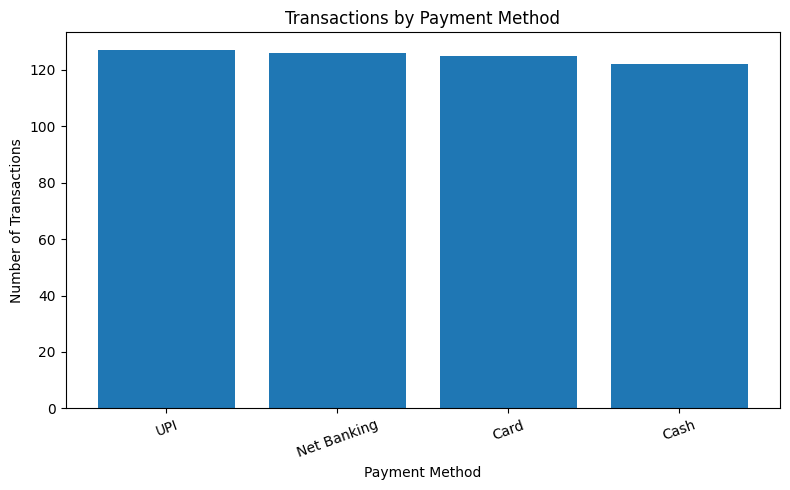

In [35]:
# Payment method chart
plt.figure(figsize=(8, 5))
plt.bar(payment_counts["Payment Method"], payment_counts["Transactions"])
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 9. Member vs Normal Customer Spending

In [36]:
customer_spending = (
    df.groupby("Customer Type")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

display(customer_spending.to_frame("Average Transaction Sales"))

member_avg = customer_spending.get("Member")
normal_avg = customer_spending.get("Normal")

print(f"Average Member transaction: ₹{member_avg:,.2f}")
print(f"Average Normal transaction: ₹{normal_avg:,.2f}")

if member_avg > normal_avg:
    print("Members have a higher average transaction value.")
elif member_avg < normal_avg:
    print("Normal customers have a higher average transaction value.")
else:
    print("Both customer types have the same average transaction value.")


,Average Transaction Sales
Customer Type,
Normal,497.07
Member,483.14


Average Member transaction: ₹483.14
Average Normal transaction: ₹497.07
Normal customers have a higher average transaction value.


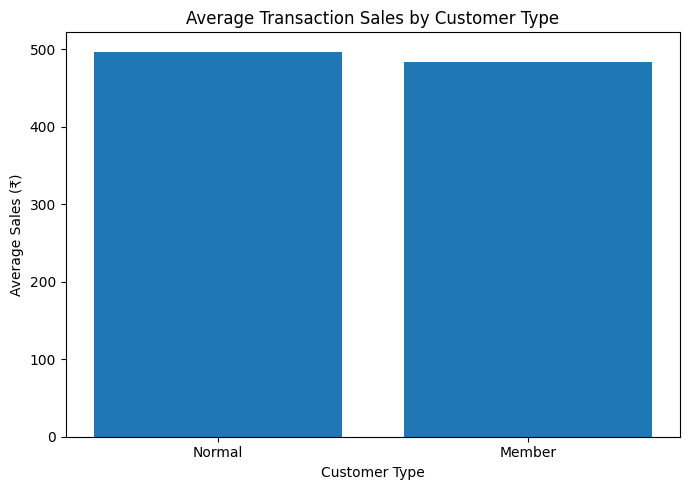

In [37]:
# Average spending by customer type
plt.figure(figsize=(7, 5))
plt.bar(customer_spending.index, customer_spending.values)
plt.title("Average Transaction Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales (₹)")
plt.tight_layout()
plt.show()


## 10. Customer Rating Analysis

In [38]:
average_rating = df["Rating"].mean()

print(f"Average customer rating: {average_rating:.2f} out of 5")

rating_summary = (
    df["Rating"]
      .round(1)
      .value_counts()
      .sort_index()
      .rename_axis("Rating")
      .reset_index(name="Number of Customers")
)

display(rating_summary)


Average customer rating: 3.99 out of 5


,Rating,Number of Customers
0,3.00,8
1,3.10,24
2,3.20,33
3,3.30,24
4,3.40,24
5,3.50,31
6,3.60,25
7,3.70,14
8,3.80,28
9,3.90,23


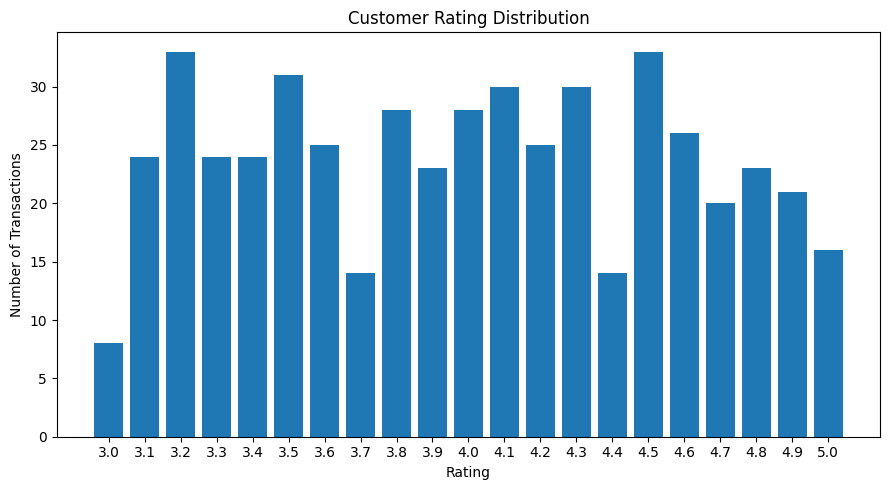

In [39]:
# Customer rating distribution
plt.figure(figsize=(9, 5))
plt.bar(rating_summary["Rating"].astype(str), rating_summary["Number of Customers"])
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## 11. Key Business Questions — Live Analysis

In [40]:
# Answer the required business questions directly from the dataset

# 1. Which product generates the highest sales?
highest_product = df.groupby("Product")["Sales"].sum().idxmax()
highest_product_sales = df.groupby("Product")["Sales"].sum().max()

# 2. Which branch performs best?
branch_totals = df.groupby(["Branch", "City"])["Sales"].sum()
best_branch_city = branch_totals.idxmax()
best_branch_sales = branch_totals.max()

# 3. Which category sells the most?
highest_category = df.groupby("Category")["Sales"].sum().idxmax()
highest_category_sales = df.groupby("Category")["Sales"].sum().max()

# 4. What is the most popular payment method?
most_popular_payment = df["Payment"].value_counts().idxmax()
most_popular_payment_count = df["Payment"].value_counts().max()

# 5. Do Members spend more than Normal customers?
member_average = df.loc[df["Customer Type"] == "Member", "Sales"].mean()
normal_average = df.loc[df["Customer Type"] == "Normal", "Sales"].mean()

# 6. What is the average customer rating?
average_rating = df["Rating"].mean()

print(f"1. Highest-sales product: {highest_product} — ₹{highest_product_sales:,.2f}")
print(f"2. Best branch: Branch {best_branch_city[0]} ({best_branch_city[1]}) — ₹{best_branch_sales:,.2f}")
print(f"3. Highest-sales category: {highest_category} — ₹{highest_category_sales:,.2f}")
print(f"4. Most popular payment method: {most_popular_payment} — {most_popular_payment_count} transactions")
print(f"5. Average Member transaction: ₹{member_average:,.2f}")
print(f"   Average Normal transaction: ₹{normal_average:,.2f}")
print(f"6. Average customer rating: {average_rating:.2f} / 5")


1. Highest-sales product: Cheese — ₹27,906.30
2. Best branch: Branch C (Mumbai) — ₹72,469.45
3. Highest-sales category: Beverages — ₹56,108.24
4. Most popular payment method: UPI — 127 transactions
5. Average Member transaction: ₹483.14
   Average Normal transaction: ₹497.07
6. Average customer rating: 3.99 / 5


## 12. Business Decisions

Based on the analysis:

- Keep sufficient stock of high-selling products and categories, especially the strongest-selling items.
- Study the factors contributing to **Branch C (Mumbai)** having the highest sales.
- Continue supporting **UPI**, which is the most-used payment method in this dataset.
- Customer ratings can be monitored to identify opportunities for improving customer service.
- The difference between Member and Normal average transaction values can be considered when planning membership offers.


## 13. Conclusion

This analysis shows how supermarket sales data can be converted into practical business insights. By grouping sales by product, branch, category, customer type, and payment method, and by analyzing customer ratings, the supermarket can better understand its performance and identify areas for operational improvement.

### Final Results
- **Highest product sales:** Cheese — **₹27,906.30**
- **Best-performing branch:** Branch C (Mumbai) — **₹72,469.45**
- **Highest category sales:** Beverages — **₹56,108.24**
- **Most-used payment method:** UPI — **127 transactions**
- **Average Member transaction:** **₹483.14**
- **Average Normal transaction:** **₹497.07**
- **Average customer rating:** **3.99 / 5**
